# **Stock Price Data Exploratory Analysis**

本项目数据来自 StockNet Dataset（Xu & Cohen, ACL 2018, *Stock Movement Prediction from Tweets and Historical Prices*），包含 2014–2016 年 88 只美股的 Twitter 推文与历史行情，公开地址为 <https://github.com/yumoxu/stocknet-dataset>。

## **Data Loading**

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0

In [8]:
# Paths
if os.path.basename(os.getcwd()) == 'notebooks':
    BASE_DIR = os.path.dirname(os.getcwd())
else:
    BASE_DIR = os.getcwd()

PRICE_DIR = os.path.join(BASE_DIR, 'data', 'price', 'preprocessed')

# Sector mapping
sector_df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'sector_map.csv'))                                                                                   
SECTOR_MAP = dict(zip(sector_df['stock'], sector_df['sector']))  

In [9]:
# Load all price data
price_cols = ['date', 'movement_pct', 'open', 'high', 'low', 'close', 'volume']
all_prices = []

for fname in sorted(os.listdir(PRICE_DIR)):
    if not fname.endswith('.txt'):
        continue
    stock = fname.replace('.txt', '')
    df = pd.read_csv(os.path.join(PRICE_DIR, fname), sep='\t', header=None, names=price_cols)
    df['stock'] = stock
    df['sector'] = SECTOR_MAP.get(stock, 'Unknown')
    all_prices.append(df)

prices = pd.concat(all_prices, ignore_index=True)
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.sort_values(['stock', 'date']).reset_index(drop=True)

# Filter to tweet overlap period
prices = prices[(prices['date'] >= '2014-01-01') & (prices['date'] <= '2015-12-31')]
prices['label'] = (prices['movement_pct'] > 0).astype(int)

print(f'Shape: {prices.shape}')
print(f'Stocks: {prices["stock"].nunique()}')
print(f'Date range: {prices["date"].min().date()} to {prices["date"].max().date()}')
prices.head()

Shape: (43442, 10)
Stocks: 87
Date range: 2014-01-02 to 2015-12-31


,date,movement_pct,open,high,low,close,volume,stock,sector,label
332,2014-01-02,-0.014064,0.064523,0.067109,0.057512,-1.048751,58671200.0,AAPL,Consumer Goods,0
333,2014-01-03,-0.021966,0.074229,0.075861,0.050077,-1.614975,98116900.0,AAPL,Consumer Goods,0
334,2014-01-06,0.005453,0.067740,0.086315,0.060091,0.392089,103152700.0,AAPL,Consumer Goods,1
335,2014-01-07,-0.007151,0.075524,0.078764,0.062878,-0.517036,79302300.0,AAPL,Consumer Goods,0
336,2014-01-08,0.006333,0.072305,0.085738,0.072066,0.454582,64632400.0,AAPL,Consumer Goods,1


## **Historical Price Analysis (Sector Leaders)**

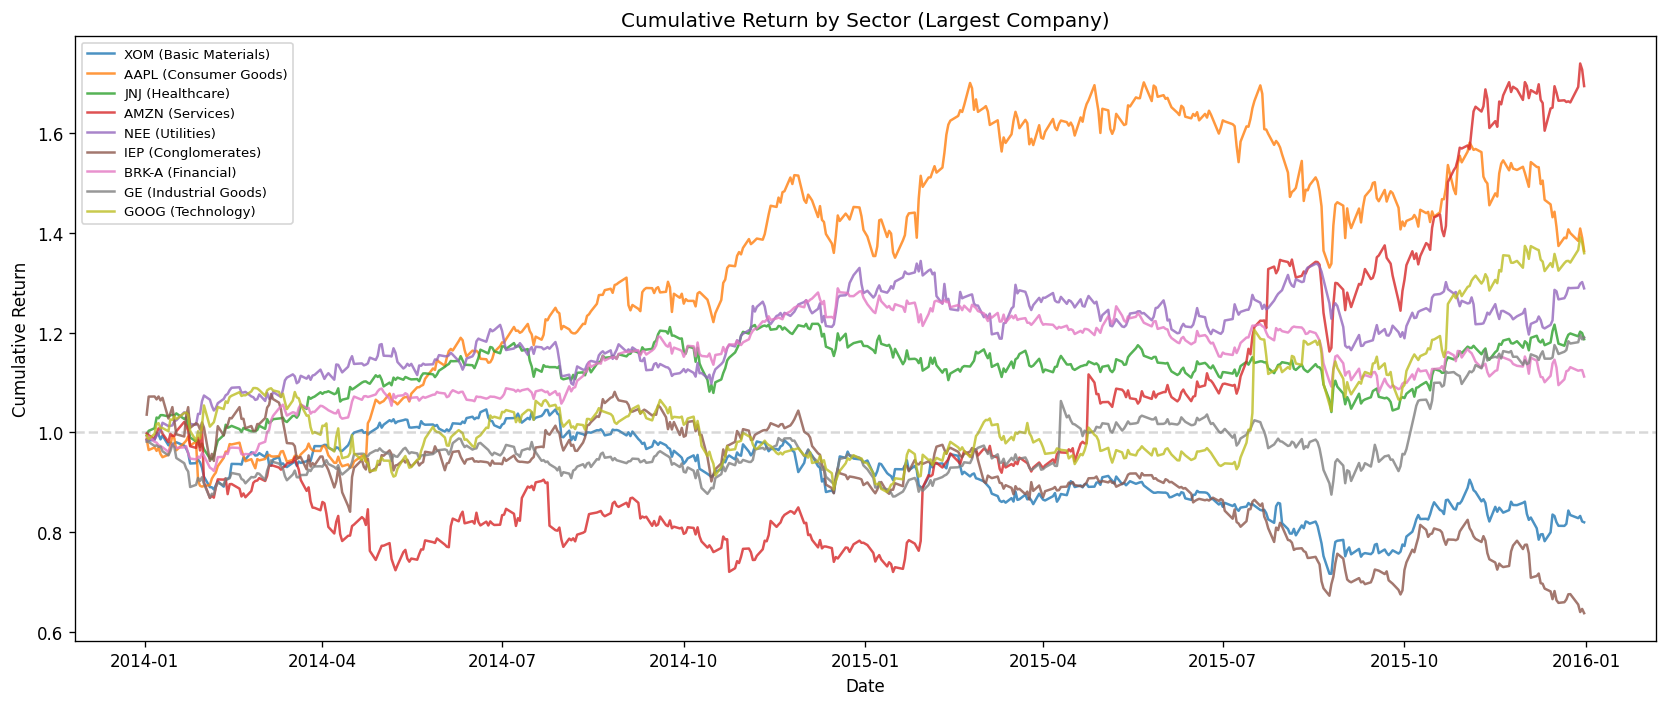

In [12]:
# Each sector's largest company (by typical market cap)
selected_stocks = ['XOM', 'AAPL', 'JNJ', 'AMZN', 'NEE', 'IEP', 'BRK-A', 'GE', 'GOOG']

fig, ax = plt.subplots(figsize=(14, 6))

for stock in selected_stocks:
  stock_data = prices[prices['stock'] == stock].sort_values('date')
  cumulative = (1 + stock_data['movement_pct']).cumprod()
  sector = stock_data['sector'].iloc[0]
  ax.plot(stock_data['date'], cumulative, label=f'{stock} ({sector})', alpha=0.8)

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.set_title('Cumulative Return by Sector (Largest Company)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### **Analysis**
- 2015年8月前后几乎所有股票同步大跌（中国股市波动引发全球 risk-off），之后分化加剧，科技/消费强势反弹，能源/工业继续承压。
- Sector 间动量差异显著，sector 或 sector-level 动量特征可能是有效的预测因子。